# Analisis Numerik PDB: Model Tegangan pada Saluran Transmisi Listrik Lossless
**Oleh:** Regan Agam (NIM: 24/PTK/552177/16439)

Saluran transmisi berfungsi menyalurkan energi listrik dari pusat pembangkit ke pusat beban. Analisis profil tegangan sangat penting untuk memastikan tegangan di ujung penerima (beban) berada dalam batas toleransi yang aman.

Proyek ini memodelkan saluran transmisi *lossless* (mengabaikan resistansi dan konduktansi) menggunakan *Ordinary Differential Equation* (ODE) orde dua:
$$ \frac{d^{2}V(x)}{dx^{2}} + \beta^{2}V(x) = 0 $$
di mana $\beta = 2.0$ adalah konstanta propagasi. Kita akan menyelesaikan model ini menggunakan metode *Initial Value Problem* (IVP) dan *Boundary Value Problem* (BVP).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETER GLOBAL & FUNGSI DASAR
# ==========================================
beta = 2.0
x_start = 0.0
x_end = np.pi / 4.0

# Kondisi Awal (IVP): V(0) = 5, V'(0) = 0
y0 = np.array([5.0, 0.0])

# Kondisi Batas (BVP): V(0) = 5, V(pi/4) = 0
bc = np.array([5.0, 0.0])

def analytical_solution(x):
    """Solusi analitis V(x) = 5 * cos(2x) sebagai pembanding keakuratan."""
    return 5.0 * np.cos(beta * x)

def model_ivp(x, y):
    """
    Sistem PDB orde 1:
    y[0] adalah y1 = V(x)
    y[1] adalah y2 = V'(x)
    """
    y1_prime = y[1]
    y2_prime = -beta**2 * y[0]
    return np.array([y1_prime, y2_prime])

## 2. Implementasi Metode Initial Value Problem (IVP)
Untuk menyelesaikan IVP, PDB orde 2 dipecah menjadi sistem PDB orde 1. Kita mengimplementasikan tiga metode komputasi dengan tingkat akurasi yang berbeda:
1. **Euler Method** (Orde 1)
2. **Midpoint Method** (Orde 2)
3. **Runge-Kutta 4th Order / RK4** (Orde 4)

In [2]:
def euler_method(f, y0, x_span, h):
    x_points = np.arange(x_span[0], x_span[1] + h, h)
    y_points = np.zeros((len(x_points), len(y0)))
    y_points[0] = y0
    for i in range(len(x_points) - 1):
        y_points[i+1] = y_points[i] + h * f(x_points[i], y_points[i])
    return x_points, y_points

def midpoint_method(f, y0, x_span, h):
    x_points = np.arange(x_span[0], x_span[1] + h, h)
    y_points = np.zeros((len(x_points), len(y0)))
    y_points[0] = y0
    for i in range(len(x_points) - 1):
        k1 = h * f(x_points[i], y_points[i])
        y_mid = y_points[i] + 0.5 * k1
        x_mid = x_points[i] + 0.5 * h
        y_points[i+1] = y_points[i] + h * f(x_mid, y_mid)
    return x_points, y_points

def rk4_method(f, y0, x_span, h):
    x_points = np.arange(x_span[0], x_span[1] + h, h)
    y_points = np.zeros((len(x_points), len(y0)))
    y_points[0] = y0
    for i in range(len(x_points) - 1):
        x_i, y_i = x_points[i], y_points[i]
        k1 = h * f(x_i, y_i)
        k2 = h * f(x_i + 0.5 * h, y_i + 0.5 * k1)
        k3 = h * f(x_i + 0.5 * h, y_i + 0.5 * k2)
        k4 = h * f(x_i + h, y_i + k3)
        y_points[i+1] = y_i + (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return x_points, y_points

## 3. Simulasi dan Analisis Error (IVP)
Selanjutnya, kita akan mengeksekusi ketiga metode di atas menggunakan variasi ukuran langkah ($h = 0.1, 0.05, 0.01$) dan memvisualisasikan tingkat konvergensinya terhadap solusi analitis.

--- EVALUASI ERROR ABSOLUT DI TITIK AKHIR (x = π/4) ---
h        | Euler        | Midpoint     | RK4            
-------------------------------------------------------
0.1      | 0.0970504    | 0.0529708    | 0.000105618


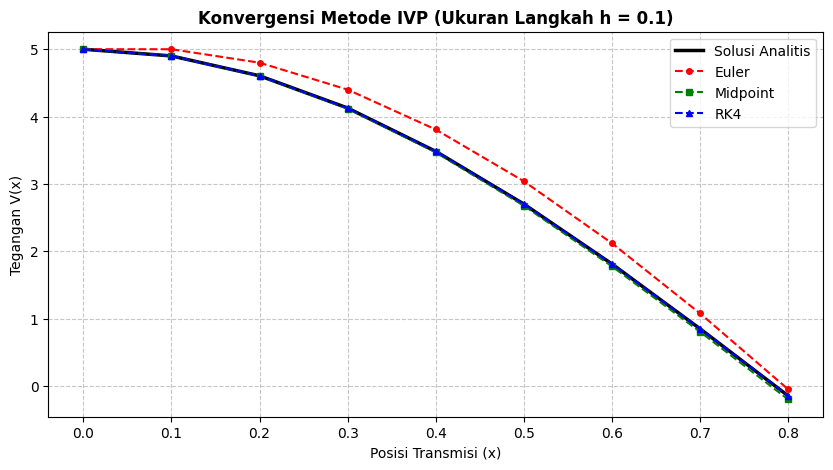

0.05     | 0.0165971    | 0.0133189    | 0.000006656


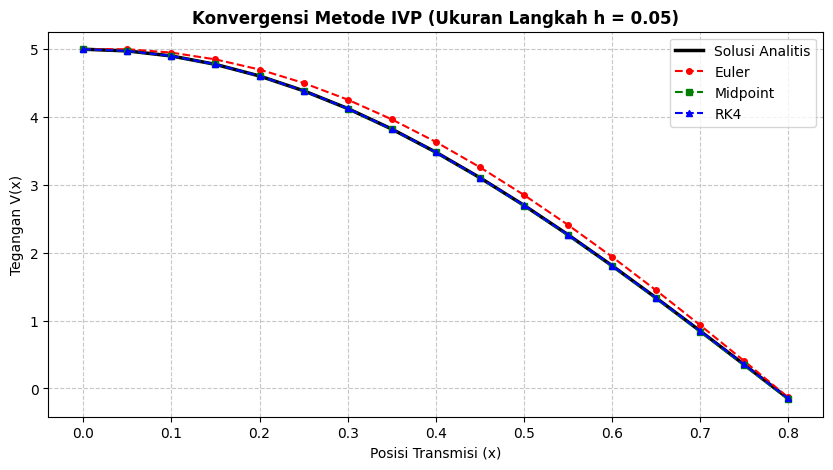

0.01     | 0.0003371    | 0.0005267    | 0.000000011


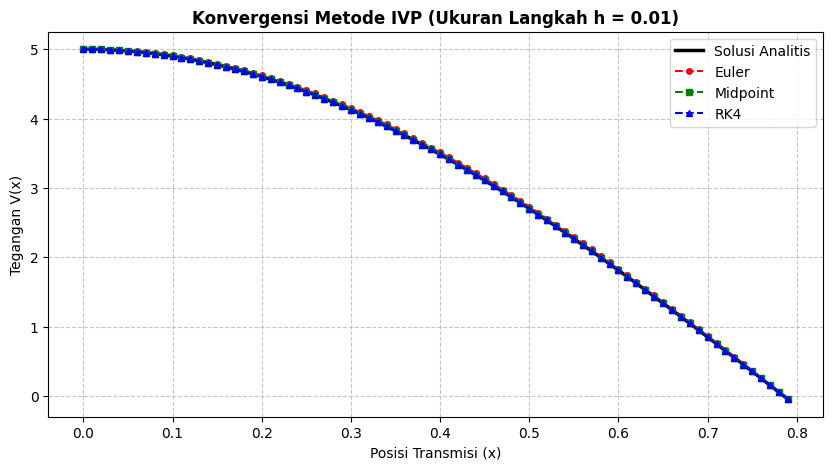

In [3]:
h_values = [0.1, 0.05, 0.01]
x_span = (x_start, x_end)

print("--- EVALUASI ERROR ABSOLUT DI TITIK AKHIR (x = π/4) ---")
print(f"{'h':<8} | {'Euler':<12} | {'Midpoint':<12} | {'RK4':<15}")
print("-" * 55)

for h in h_values:
    # Komputasi
    x_euler, y_euler = euler_method(model_ivp, y0, x_span, h)
    x_mid, y_mid = midpoint_method(model_ivp, y0, x_span, h)
    x_rk4, y_rk4 = rk4_method(model_ivp, y0, x_span, h)

    v_euler, v_mid, v_rk4 = y_euler[:, 0], y_mid[:, 0], y_rk4[:, 0]
    v_analytical = analytical_solution(x_euler)

    # Kalkulasi Error
    err_euler = abs(v_euler[-1] - v_analytical[-1])
    err_mid = abs(v_mid[-1] - v_analytical[-1])
    err_rk4 = abs(v_rk4[-1] - v_analytical[-1])

    print(f"{h:<8} | {err_euler:.7f}    | {err_mid:.7f}    | {err_rk4:.9f}")

    # Plotting untuk setiap nilai h
    plt.figure(figsize=(10, 5))
    plt.plot(x_euler, v_analytical, 'k-', linewidth=2.5, label='Solusi Analitis')
    plt.plot(x_euler, v_euler, 'r--o', markersize=4, label='Euler')
    plt.plot(x_mid, v_mid, 'g--s', markersize=4, label='Midpoint')
    plt.plot(x_rk4, v_rk4, 'b--^', markersize=4, label='RK4')
    plt.title(f'Konvergensi Metode IVP (Ukuran Langkah h = {h})', fontweight='bold')
    plt.xlabel('Posisi Transmisi (x)')
    plt.ylabel('Tegangan V(x)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## 4. Implementasi Boundary Value Problem (BVP)
Dalam praktiknya, kita sering kali hanya mengetahui nilai tegangan di dua ujung saluran (gardu induk dan gardu distribusi). Untuk kasus nilai batas ini, kita menggunakan metode **Finite Difference Discretization** dengan membangun matriks algebra linear $Av = b$.

In [4]:
def finite_difference_bvp(beta_sq, x_span, bc, h):
    x_points = np.arange(x_span[0], x_span[1] + h, h)
    N = len(x_points) - 2  # Jumlah titik interior

    # Matriks Sistem A
    A = np.zeros((N, N))
    main_diag = (beta_sq * h**2 - 2) * np.ones(N)
    off_diag = np.ones(N - 1)
    np.fill_diagonal(A, main_diag)
    np.fill_diagonal(A[1:], off_diag)
    np.fill_diagonal(A[:, 1:], off_diag)

    # Vektor b dari kondisi batas
    b = np.zeros(N)
    b[0] = -bc[0]
    b[-1] = -bc[1]

    # Solusi persamaan linear
    v_internal = np.linalg.solve(A, b)
    v_solution = np.concatenate(([bc[0]], v_internal, [bc[1]]))

    return x_points, v_solution

## 5. Simulasi BVP dan Kesimpulan
Mengevaluasi akurasi metode *Finite Difference* pada variasi ukuran langkah $h$.

--- EVALUASI ERROR MAKSIMUM BVP ---
h        | Finite Difference Max Error
----------------------------------------
0.1      | 0.1459976


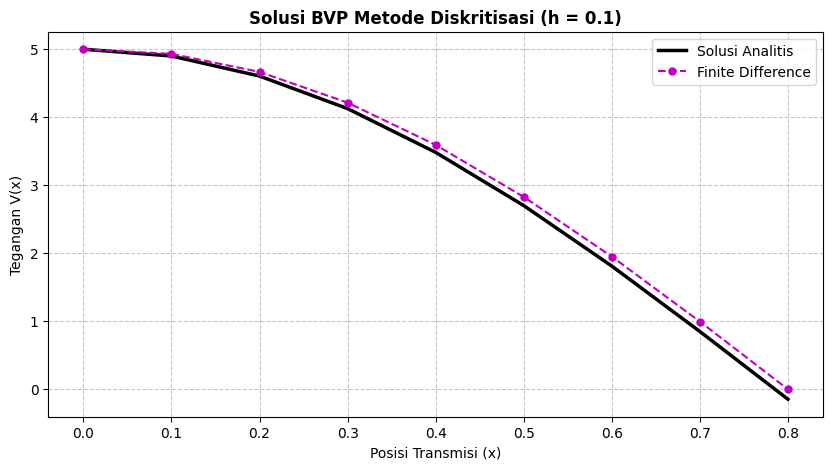

0.05     | 0.1459976


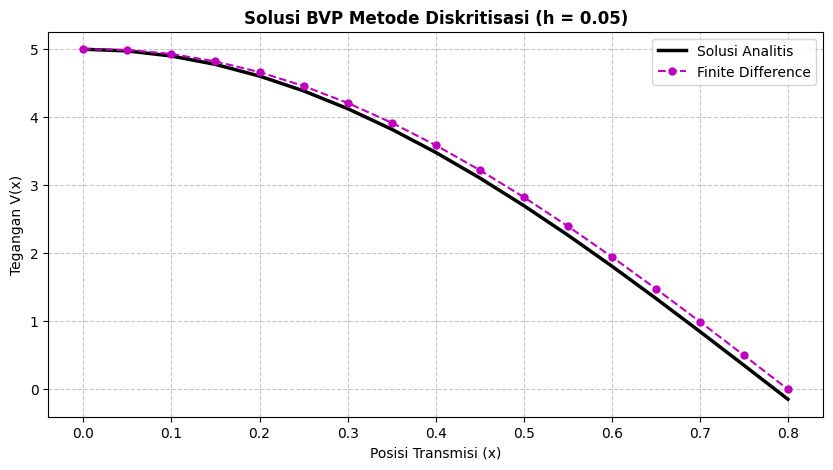

0.01     | 0.0460187


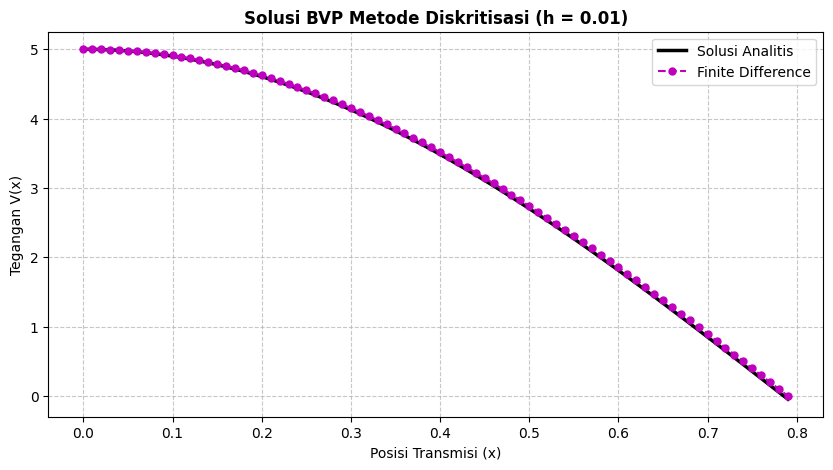

In [5]:
print("--- EVALUASI ERROR MAKSIMUM BVP ---")
print(f"{'h':<8} | {'Finite Difference Max Error'}")
print("-" * 40)

for h in h_values:
    x_bvp, v_bvp = finite_difference_bvp(beta**2, x_span, bc, h)
    v_analytical_bvp = analytical_solution(x_bvp)

    max_error = np.max(np.abs(v_bvp - v_analytical_bvp))
    print(f"{h:<8} | {max_error:.7f}")

    plt.figure(figsize=(10, 5))
    plt.plot(x_bvp, v_analytical_bvp, 'k-', linewidth=2.5, label='Solusi Analitis')
    plt.plot(x_bvp, v_bvp, 'm--o', markersize=5, label='Finite Difference')
    plt.title(f'Solusi BVP Metode Diskritisasi (h = {h})', fontweight='bold')
    plt.xlabel('Posisi Transmisi (x)')
    plt.ylabel('Tegangan V(x)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()